<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/ml_example_notebook/model_eval_classification.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

### 분류 모델 평가 지표 (Classification Model Evaluation Metrics)

#### 📊 1. 혼동 행렬 (Confusion Matrix)
- **True Positive (TP)**: 실제 양성을 양성으로 올바르게 예측
- **True Negative (TN)**: 실제 음성을 음성으로 올바르게 예측
- **False Positive (FP)**: 음성을 양성으로 잘못 예측 (1종 오류, Type I Error)
- **False Negative (FN)**: 양성을 음성으로 잘못 예측 (2종 오류, Type II Error)

---

#### 🎯 2. 기본 평가 지표

##### 2.1 정확도 (Accuracy)
- **정의**: 전체 예측 중 올바른 예측의 비율
- **공식**: `(TP + TN) / (TP + TN + FP + FN)`
- **특징**: 
  - 가장 직관적인 지표
  - 클래스 불균형 시 오해의 소지 있음
  - 예: 99% 음성 데이터에서 항상 음성 예측 → 99% 정확도

##### 2.2 정밀도 (Precision)
- **정의**: 양성으로 예측한 것 중 실제 양성의 비율
- **공식**: `TP / (TP + FP)`
- **의미**: "양성이라고 예측한 것이 얼마나 정확한가?"
- **중요한 경우**: 
  - 스팸 필터 (정상 메일을 스팸으로 분류하면 안됨)
  - 상품 추천 시스템 (잘못된 추천 최소화)

##### 2.3 재현율 (Recall / Sensitivity / TPR)
- **정의**: 실제 양성 중 올바르게 찾아낸 비율
- **공식**: `TP / (TP + FN)`
- **의미**: "실제 양성을 얼마나 잘 찾아냈는가?"
- **중요한 경우**:
  - 암 진단 (환자를 놓치면 안됨)
  - 사기 탐지 (사기 거래 누락 방지)

##### 2.4 F1-Score
- **정의**: Precision과 Recall의 조화평균
- **공식**: `2 × (Precision × Recall) / (Precision + Recall)`
- **특징**:
  - 둘 다 중요할 때 균형잡힌 지표
  - 클래스 불균형 문제에서 Accuracy보다 유용
  - 0~1 사이 값, 높을수록 좋음

---

#### 📈 3. 확률 기반 지표

##### 3.1 ROC 곡선 (Receiver Operating Characteristic)
- **구성**: FPR(x축) vs TPR(y축)
- **FPR (False Positive Rate)**: `FP / (FP + TN)`
- **TPR (True Positive Rate)**: Recall과 동일
- **해석**: 곡선이 왼쪽 위에 가까울수록 좋은 모델

##### 3.2 AUC (Area Under the ROC Curve)
- **범위**: 0 ~ 1
- **해석**:
  - AUC = 1.0: 완벽한 분류기
  - AUC = 0.5: 랜덤 추측 수준
  - AUC > 0.9: 매우 우수한 모델
  - AUC > 0.8: 좋은 모델
- **장점**: 임계값에 독립적인 평가

##### 3.3 Precision-Recall 곡선
- **구성**: Recall(x축) vs Precision(y축)
- **AP (Average Precision)**: PR 곡선 아래 면적
- **특징**: 클래스 불균형 데이터에서 ROC보다 유용

---

#### ⚠️ 4. 클래스 불균형 상황

##### 4.1 문제점
- 소수 클래스 예측 실패해도 높은 Accuracy
- 예: 암 환자 1%, 모두 정상 예측 → 99% 정확도

##### 4.2 대응 방법
- **평가 지표**: Precision, Recall, F1-Score, PR-AUC 사용
- **샘플링**: Over-sampling (SMOTE), Under-sampling
- **가중치**: Class weight 조정
- **임계값 조정**: 확률 임계값 최적화

---

#### 🎨 5. 다중 클래스 분류

##### 5.1 평균 방법
- **Macro Average**: 각 클래스를 동등하게 취급
  - `(Class1 + Class2 + ... + ClassN) / N`
  - 소수 클래스 성능도 중요할 때

- **Micro Average**: 전체 샘플 기준 계산
  - 전체 TP, FP, FN 합산 후 계산
  - 클래스 불균형 무시

- **Weighted Average**: 각 클래스 샘플 수로 가중 평균
  - 클래스 크기 고려
  - 가장 실용적

---

#### 💡 6. 지표 선택 가이드

| 상황 | 추천 지표 | 이유 |
|------|-----------|------|
| 균형잡힌 데이터 | Accuracy | 직관적이고 충분함 |
| 불균형 데이터 | F1-Score, PR-AUC | Accuracy 오도 방지 |
| FP 비용 큼 | Precision | 잘못된 양성 예측 최소화 |
| FN 비용 큼 | Recall | 양성 놓침 방지 |
| 전반적 성능 | ROC-AUC | 임계값 독립적 |
| 희귀 클래스 탐지 | PR-AUC | 불균형에 민감 |



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 시드 고정
np.random.seed(42)

In [12]:
# ## 📊 Part 1: 분류(Classification) 평가 지표

# ### 1.1 데이터 준비 - 유방암 데이터셋

# 실제 데이터셋 로드
data = load_breast_cancer()
X, y = data.data, data.target

# 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 모델 학습
clf = LogisticRegression(max_iter=10000, random_state=42)
clf.fit(X_train, y_train)

# 예측
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # 양성 클래스 확률

print(f"데이터셋 크기: {X.shape}")
print(f"클래스 분포: {np.bincount(y)}")
print(f"테스트 셋 크기: {len(y_test)}")

데이터셋 크기: (569, 30)
클래스 분포: [212 357]
테스트 셋 크기: 171


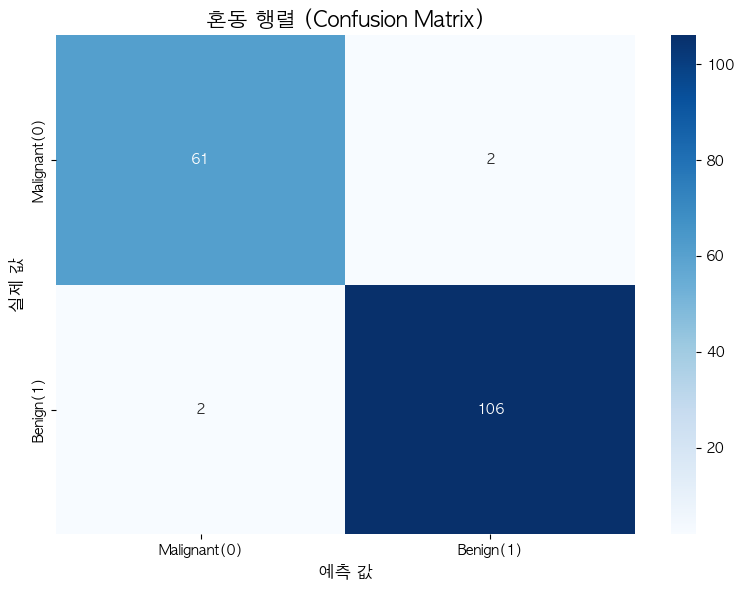

In [4]:
# ### 1.2 기본 분류 지표: Accuracy, Precision, Recall

# 📌 Confusion Matrix (혼동 행렬)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant(0)", "Benign(1)"],
    yticklabels=["Malignant(0)", "Benign(1)"],
)
plt.title("혼동 행렬 (Confusion Matrix)", fontsize=15, fontweight="bold")
plt.ylabel("실제 값", fontsize=12)
plt.xlabel("예측 값", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# 지표 계산
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [6]:
print("📊 분류 평가 지표")
print("=" * 50)
print(f"True Negative (TN):  {tn:4d}  | 올바르게 음성으로 예측")
print(f"False Positive (FP): {fp:4d}  | 음성을 양성으로 잘못 예측 (1종 오류)")
print(f"False Negative (FN): {fn:4d}  | 양성을 음성으로 잘못 예측 (2종 오류)")
print(f"True Positive (TP):  {tp:4d}  | 올바르게 양성으로 예측")
print("=" * 50)
print(f"✅ Accuracy (정확도):  {accuracy:.4f}")
print("   → 전체 중 맞춘 비율 = (TP+TN) / (TP+TN+FP+FN)")
print(f"\n✅ Precision (정밀도): {precision:.4f}")
print("   → 양성 예측 중 실제 양성 비율 = TP / (TP+FP)")
print("   → '양성'이라 예측한 것 중 얼마나 정확한가?")
print(f"\n✅ Recall (재현율):    {recall:.4f}")
print("   → 실제 양성 중 찾아낸 비율 = TP / (TP+FN)")
print("   → 실제 '양성'을 얼마나 잘 찾아냈는가?")
print(f"\n✅ F1-Score:           {f1:.4f}")
print("   → Precision과 Recall의 조화평균")
print("=" * 50)

📊 분류 평가 지표
True Negative (TN):    61  | 올바르게 음성으로 예측
False Positive (FP):    2  | 음성을 양성으로 잘못 예측 (1종 오류)
False Negative (FN):    2  | 양성을 음성으로 잘못 예측 (2종 오류)
True Positive (TP):   106  | 올바르게 양성으로 예측
✅ Accuracy (정확도):  0.9766
   → 전체 중 맞춘 비율 = (TP+TN) / (TP+TN+FP+FN)

✅ Precision (정밀도): 0.9815
   → 양성 예측 중 실제 양성 비율 = TP / (TP+FP)
   → '양성'이라 예측한 것 중 얼마나 정확한가?

✅ Recall (재현율):    0.9815
   → 실제 양성 중 찾아낸 비율 = TP / (TP+FN)
   → 실제 '양성'을 얼마나 잘 찾아냈는가?

✅ F1-Score:           0.9815
   → Precision과 Recall의 조화평균



💡 Precision vs Recall 트레이드오프
--------------------------------------------------
Precision 중요: 스팸 필터 (정상 메일을 스팸으로 분류하면 안됨)
Recall 중요:    암 진단 (암 환자를 놓치면 안됨)
F1-Score:       둘 다 중요할 때 균형잡힌 지표
--------------------------------------------------


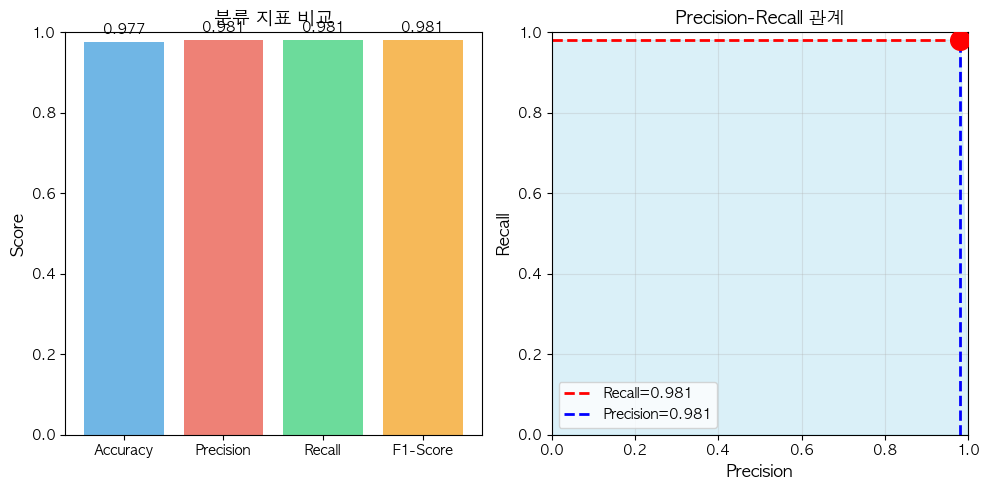

In [7]:
# ### 1.3 F1-Score의 의미

print("\n💡 Precision vs Recall 트레이드오프")
print("-" * 50)
print("Precision 중요: 스팸 필터 (정상 메일을 스팸으로 분류하면 안됨)")
print("Recall 중요:    암 진단 (암 환자를 놓치면 안됨)")
print("F1-Score:       둘 다 중요할 때 균형잡힌 지표")
print("-" * 50)

# Precision-Recall 시각화
plt.figure(figsize=(10, 5))

# 서브플롯 1: 지표 비교
plt.subplot(1, 2, 1)
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
bars = plt.bar(metrics, values, color=colors, alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("Score", fontsize=12)
plt.title("분류 지표 비교", fontsize=13, fontweight="bold")
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

# 서브플롯 2: Precision-Recall 관계
plt.subplot(1, 2, 2)
x = np.array([0, precision, 1])
y = np.array([recall, recall, 0])
plt.fill_between(x, y, alpha=0.3, color="skyblue")
plt.plot(
    [0, precision], [recall, recall], "r--", linewidth=2, label=f"Recall={recall:.3f}"
)
plt.plot(
    [precision, precision],
    [0, recall],
    "b--",
    linewidth=2,
    label=f"Precision={precision:.3f}",
)
plt.scatter([precision], [recall], s=200, c="red", marker="o", zorder=5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Precision", fontsize=12)
plt.ylabel("Recall", fontsize=12)
plt.title("Precision-Recall 관계", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

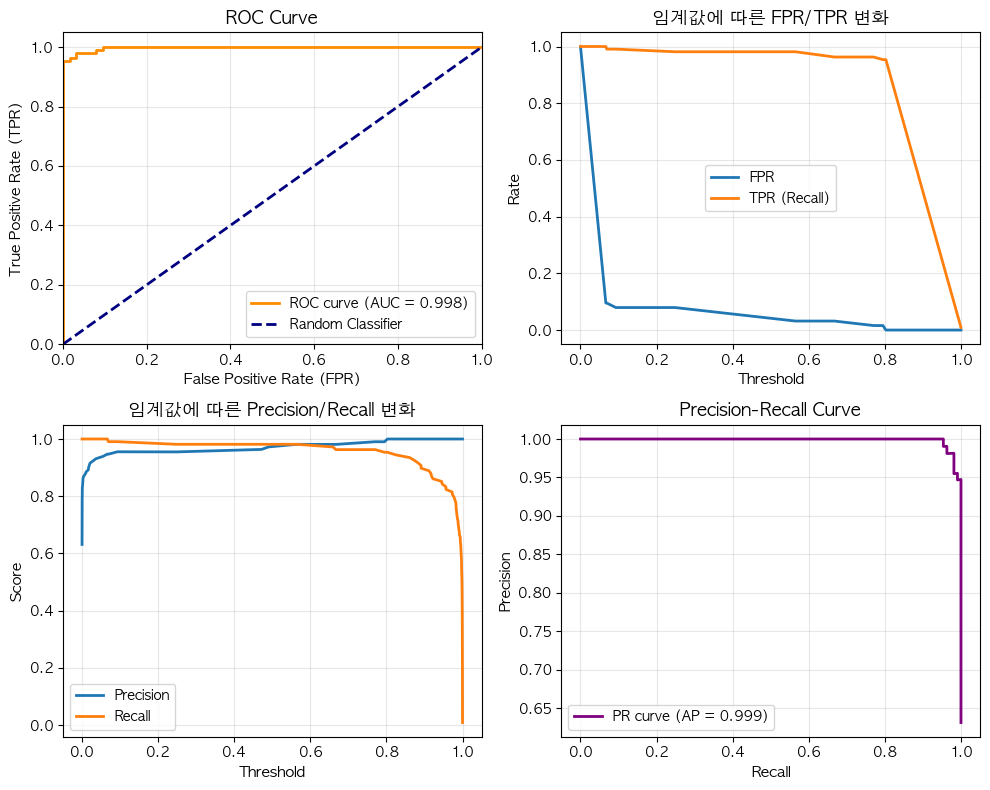


📊 ROC-AUC & PR 분석
ROC-AUC Score:              0.9976
Average Precision (AP):     0.9987
💡 해석:
  - AUC = 1.0: 완벽한 분류기
  - AUC = 0.5: 랜덤 추측 수준
  - AUC > 0.9: 매우 우수한 모델


In [8]:
# ### 1.4 ROC 곡선과 AUC

# ROC 곡선 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 시각화
plt.figure(figsize=(10, 8))

# ROC 곡선
plt.subplot(2, 2, 1)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.title("ROC Curve", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 임계값에 따른 FPR, TPR 변화
plt.subplot(2, 2, 2)
plt.plot(thresholds, fpr, label="FPR", linewidth=2)
plt.plot(thresholds, tpr, label="TPR (Recall)", linewidth=2)
plt.xlabel("Threshold", fontsize=11)
plt.ylabel("Rate", fontsize=11)
plt.title("임계값에 따른 FPR/TPR 변화", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

# 임계값별 Precision, Recall
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test, y_pred_proba
)
plt.subplot(2, 2, 3)
plt.plot(pr_thresholds, precision_curve[:-1], label="Precision", linewidth=2)
plt.plot(pr_thresholds, recall_curve[:-1], label="Recall", linewidth=2)
plt.xlabel("Threshold", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.title("임계값에 따른 Precision/Recall 변화", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

# Precision-Recall 곡선
avg_precision = average_precision_score(y_test, y_pred_proba)
plt.subplot(2, 2, 4)
plt.plot(
    recall_curve,
    precision_curve,
    color="purple",
    lw=2,
    label=f"PR curve (AP = {avg_precision:.3f})",
)
plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Precision-Recall Curve", fontsize=13, fontweight="bold")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 ROC-AUC & PR 분석")
print("=" * 50)
print(f"ROC-AUC Score:              {roc_auc:.4f}")
print(f"Average Precision (AP):     {avg_precision:.4f}")
print("=" * 50)
print("💡 해석:")
print("  - AUC = 1.0: 완벽한 분류기")
print("  - AUC = 0.5: 랜덤 추측 수준")
print("  - AUC > 0.9: 매우 우수한 모델")
print("=" * 50)

In [9]:
# ### 1.5 클래스 불균형 상황에서의 평가

# 불균형 데이터 생성
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    weights=[0.9, 0.1],  # 9:1 불균형
    random_state=42,
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42
)

# 모델 학습
clf_imb = LogisticRegression(max_iter=10000, random_state=42)
clf_imb.fit(X_train_imb, y_train_imb)

y_pred_imb = clf_imb.predict(X_test_imb)
y_pred_proba_imb = clf_imb.predict_proba(X_test_imb)[:, 1]

# 평가
print("\n⚠️ 클래스 불균형 데이터 (90% vs 10%)")
print("=" * 50)
print(f"클래스 분포: {np.bincount(y_test_imb)}")
print(f"Accuracy:  {accuracy_score(y_test_imb, y_pred_imb):.4f}")
print(f"Precision: {precision_score(y_test_imb, y_pred_imb):.4f}")
print(f"Recall:    {recall_score(y_test_imb, y_pred_imb):.4f}")
print(f"F1-Score:  {f1_score(y_test_imb, y_pred_imb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_imb, y_pred_proba_imb):.4f}")
print("=" * 50)
print("💡 불균형 데이터에서는:")
print("  - Accuracy는 높아도 소수 클래스 예측 실패 가능")
print("  - Precision, Recall, F1-Score가 더 중요")
print("  - PR 곡선이 ROC 곡선보다 더 유용")
print("=" * 50)


⚠️ 클래스 불균형 데이터 (90% vs 10%)
클래스 분포: [274  26]
Accuracy:  0.9233
Precision: 0.5882
Recall:    0.3846
F1-Score:  0.4651
ROC-AUC:   0.9019
💡 불균형 데이터에서는:
  - Accuracy는 높아도 소수 클래스 예측 실패 가능
  - Precision, Recall, F1-Score가 더 중요
  - PR 곡선이 ROC 곡선보다 더 유용



🎯 다중 클래스 분류 평가 (3개 클래스)
Accuracy: 0.9133

평균 방법별 F1-Score:
  Macro F1    (각 클래스 동등 가중): 0.9145
  Micro F1    (전체 샘플 기준):      0.9133
  Weighted F1 (샘플 수 가중 평균):   0.9135

📋 분류 상세 리포트:
              precision    recall  f1-score   support

     Class 0       0.88      0.91      0.89        55
     Class 1       0.93      0.91      0.92        45
     Class 2       0.94      0.92      0.93        50

    accuracy                           0.91       150
   macro avg       0.92      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



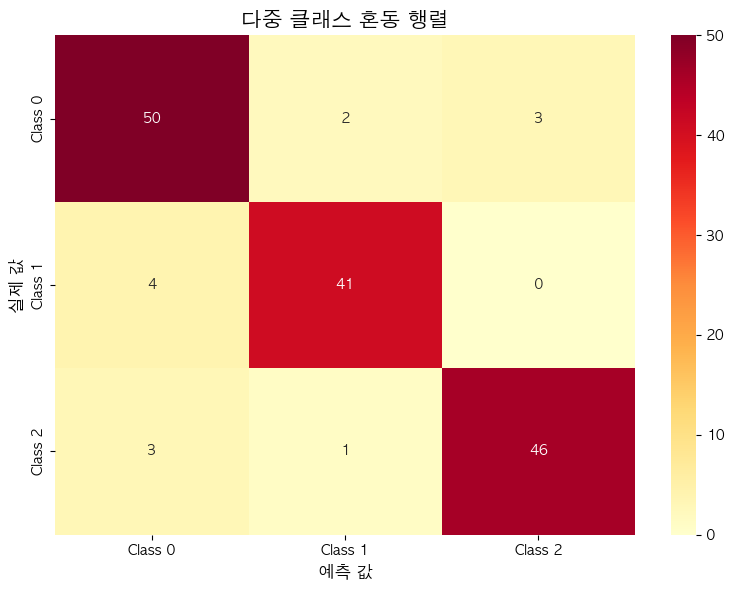

In [10]:
# ### 1.6 다중 클래스 분류 평가

# 다중 클래스 데이터 생성
X_multi, y_multi = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

# 모델 학습
clf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
clf_multi.fit(X_train_m, y_train_m)
y_pred_m = clf_multi.predict(X_test_m)

# 다양한 평균 방법 비교
print("\n🎯 다중 클래스 분류 평가 (3개 클래스)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_m, y_pred_m):.4f}")
print("\n평균 방법별 F1-Score:")
print(
    f"  Macro F1    (각 클래스 동등 가중): {f1_score(y_test_m, y_pred_m, average='macro'):.4f}"
)
print(
    f"  Micro F1    (전체 샘플 기준):      {f1_score(y_test_m, y_pred_m, average='micro'):.4f}"
)
print(
    f"  Weighted F1 (샘플 수 가중 평균):   {f1_score(y_test_m, y_pred_m, average='weighted'):.4f}"
)
print("=" * 50)

# 클래스별 상세 리포트
print("\n📋 분류 상세 리포트:")
print(
    classification_report(
        y_test_m, y_pred_m, target_names=[f"Class {i}" for i in range(3)]
    )
)

# 혼동 행렬
cm_multi = confusion_matrix(y_test_m, y_pred_m)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    xticklabels=[f"Class {i}" for i in range(3)],
    yticklabels=[f"Class {i}" for i in range(3)],
)
plt.title("다중 클래스 혼동 행렬", fontsize=15, fontweight="bold")
plt.ylabel("실제 값", fontsize=12)
plt.xlabel("예측 값", fontsize=12)
plt.tight_layout()
plt.show()